# 04 — Phase Trajectory Conditioning (Sub-contribution 2, MAIN)

이 프로젝트의 핵심 기여. PAPL 같은 step-wise RL 방법과 결정적 차이를 만드는 부분.

**Step 3 (Periodic Phase) 대비 변경**:
| 항목 | Step 3 (Periodic) | Step 4 (Trajectory) |
|---|---|---|
| `global_cond` | `OH·OD + 2` (obs + φ_0) | `OH·OD` (obs only) |
| `per_step_cond` | None | `(B, PH, 2)` — `(cos φ_t, sin φ_t)` for each chunk step |
| Conditioning 메커니즘 | global FiLM only | global FiLM + per-step FiLM (zero-init delta-scale) |
| Architecture 변경 | `ConditionalUnet1D` 그대로 | 새 `PhaseConditionedUnet1D` 클래스 |
| 기대 효과 | Controllability 약함 (Step 3 결과로 검증됨) | Sampling-time controllability 작동 |

**핵심 검증 — 같은 sweep을 Step 3과 비교**:
- Freq sweep RMSE가 Δf↑ 일수록 monotonic 증가? (Step 3은 평탄)
- Rollout reward가 freq별로 변화? (Step 3은 245–330 평탄)
- OOD에서 명확한 성능 저하? (Step 3은 OOD도 멀쩡함)

위 셋 모두 yes면 sub-contribution 2 입증.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
PROJECT_DIR = '/content/drive/MyDrive/quadruped_diffusion_project'
SRC_DIR = f'{PROJECT_DIR}/src'
assert os.path.exists(SRC_DIR)
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"✓ Drive mounted")
print(f"  src 파일: {[f for f in os.listdir(SRC_DIR) if f.endswith('.py')]}")

Mounted at /content/drive
✓ Drive mounted
  src 파일: ['dataset.py', 'training.py', 'models.py', 'sampling.py']


In [2]:
!pip install -q "diffusers>=0.30,<0.32" "huggingface_hub>=0.23" "gymnasium[mujoco]"
print("✓ 의존성 준비 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 20.6 MB/s eta 0:00:00
✓ 의존성 준비 완료


In [3]:
import time
import shutil
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.training_utils import EMAModel

from dataset  import load_project_data, build_loaders
from models   import build_phase_trajectory_dp_model, count_params
from training import (
    train_diffusion_policy, trajectory_phase_cond_fn,
    save_checkpoint, load_checkpoint,
)
from sampling import (
    sample_action_chunk, rollout, rollout_multi_seed,
    trajectory_phase_sample_cond_fn, diagnose_obs_distribution,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__}, device={device}")

PyTorch 2.10.0+cu128, device=cuda


## 2. 데이터 로드

In [4]:
data = load_project_data(PROJECT_DIR)

print(f"OBS_DIM={data['OBS_DIM']}, ACT_DIM={data['ACT_DIM']}")
print(f"Freq window: {data['freq_window_mean']:.3f} ± {data['freq_window_std']:.3f} Hz")

SEED = data['seed']
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 256
train_ds, val_ds, train_loader, val_loader = build_loaders(
    data, batch_size=BATCH_SIZE, num_workers=2,
)

OBS_DIM=105, ACT_DIM=8
Freq window: 2.023 ± 0.102 Hz
Train dataset:
  AntPhaseDataset: 102 episodes → 18768 chunks
Val dataset:
  AntPhaseDataset: 18 episodes → 3312 chunks
  Train batches/epoch: 73
  Val batches/epoch:   13


## 3. 모델 빌드 — PhaseConditionedUnet1D

Per-step FiLM이 zero-init이라 학습 시작 시점에는 vanilla DP와 정확히 같은 출력. 학습 진행하면서 모델이 per-step phase 정보 사용 시작.

In [5]:
model = build_phase_trajectory_dp_model(
    obs_dim=data['OBS_DIM'],
    act_dim=data['ACT_DIM'],
    obs_horizon=data['OBS_HORIZON'],
    per_step_cond_dim=2,    # (cos φ, sin φ)
    diffusion_step_embed_dim=256,
    down_dims=(256, 512, 1024),
    device=device,
)
n = count_params(model)
print(f"Total params:     {n['total']/1e6:.2f}M")
print(f"Trainable params: {n['trainable']/1e6:.2f}M")
print(f"global_cond_dim:  {data['OBS_HORIZON'] * data['OBS_DIM']}")
print(f"per_step_cond_dim: 2 (cos, sin)")

Total params:     68.27M
Trainable params: 68.27M
global_cond_dim:  210
per_step_cond_dim: 2 (cos, sin)


## 4. Forward pass sanity + zero-init 검증

학습 직전 상태에서, 같은 obs/timestep로 (1) 임의 phase trajectory와 (2) zero phase trajectory를 줬을 때 출력이 정확히 같아야 함 (per_step encoder가 zero-init이라).

In [6]:
B = 4
fake_action = torch.randn(B, data['PRED_HORIZON'], data['ACT_DIM'], device=device)
fake_t = torch.randint(0, 100, (B,), device=device)
fake_global = torch.randn(B, data['OBS_HORIZON'] * data['OBS_DIM'], device=device)
fake_phase_a = torch.randn(B, data['PRED_HORIZON'], 2, device=device)
fake_phase_b = torch.zeros(B, data['PRED_HORIZON'], 2, device=device)

with torch.no_grad():
    out_a = model(fake_action, fake_t, fake_global, fake_phase_a)
    out_b = model(fake_action, fake_t, fake_global, fake_phase_b)
    out_c = model(fake_action, fake_t, fake_global, fake_phase_a * 100)  # 큰 phase

assert out_a.shape == fake_action.shape
print(f"✓ Forward pass: in {tuple(fake_action.shape)} → out {tuple(out_a.shape)}")
print(f"\n=== Zero-init 검증 ===")
print(f"|out(phase_random) - out(phase_zero)|:  {(out_a - out_b).abs().max():.2e}")
print(f"|out(phase_random) - out(phase_x100)|:  {(out_a - out_c).abs().max():.2e}")
print(f"→ 두 값 모두 ~0 이어야 zero-init 정합. 학습 시작 시 phase 영향 = 0.")

✓ Forward pass: in (4, 16, 8) → out (4, 16, 8)

=== Zero-init 검증 ===
|out(phase_random) - out(phase_zero)|:  0.00e+00
|out(phase_random) - out(phase_x100)|:  0.00e+00
→ 두 값 모두 ~0 이어야 zero-init 정합. 학습 시작 시 phase 영향 = 0.


## 5. Conditioning 추출 sanity

In [7]:
sample_batch = next(iter(train_loader))
print("Batch keys + shapes:")
for k, v in sample_batch.items():
    print(f"  {k}: {tuple(v.shape)}")

global_cond, per_step_cond = trajectory_phase_cond_fn(sample_batch, device)
print(f"\nglobal_cond:   {tuple(global_cond.shape)}  (B, OH*OD)")
print(f"per_step_cond: {tuple(per_step_cond.shape)}  (B, PH, 2)")

# 모든 step에서 cos²+sin²=1 검증
norms = (per_step_cond ** 2).sum(dim=-1).sqrt()
print(f"\n(cos² + sin²)^0.5 per step:  mean={norms.mean():.6f}, "
      f"min={norms.min():.6f}, max={norms.max():.6f}")
assert torch.allclose(norms, torch.ones_like(norms), atol=1e-5)
print("✓ Per-step phase encoding 정합")

Batch keys + shapes:
  obs: (256, 2, 105)
  action: (256, 16, 8)
  phase: (256, 16)

global_cond:   (256, 210)  (B, OH*OD)
per_step_cond: (256, 16, 2)  (B, PH, 2)

(cos² + sin²)^0.5 per step:  mean=1.000000, min=1.000000, max=1.000000
✓ Per-step phase encoding 정합


## 6. Noise scheduler

In [8]:
NUM_TRAIN_TIMESTEPS = 100
NUM_INFERENCE_STEPS  = 16

noise_scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    beta_schedule='squaredcos_cap_v2',
    prediction_type='epsilon',
    clip_sample=True,
)
ns_config = {
    'num_train_timesteps': noise_scheduler.config.num_train_timesteps,
    'beta_schedule':       noise_scheduler.config.beta_schedule,
    'prediction_type':     noise_scheduler.config.prediction_type,
    'clip_sample':         noise_scheduler.config.clip_sample,
}
print("DDPM ready")

DDPM ready


## 7. 학습

`NUM_EPOCHS=60` (Step 3과 동일 — 공정 비교를 위해 hyperparam 통일).

**예상 흐름**:
- 학습 초기: per-step encoder zero-init이라 모델이 거의 vanilla처럼 동작 (loss가 vanilla 수준)
- 학습 진행: per-step encoder가 점진적으로 학습 → loss가 vanilla보다 더 떨어질 수도 (phase 정보로 추가 fitting 가능)
- 만약 loss가 vanilla와 동일 수준에서 평탄 → 모델이 per-step phase를 안 쓰는 거. 이상 신호.

In [9]:
TRAIN = True   # 첫 실행시 True. 재실행시 False.
NUM_EPOCHS = 60
CKPT_PATH = f'{PROJECT_DIR}/phase_trajectory_ckpt.pt'

ema = EMAModel(parameters=model.parameters(), power=0.75)

if TRAIN:
    train_losses, val_log, best_ema_state = train_diffusion_policy(
        model, ema, noise_scheduler,
        train_loader, val_loader,
        cond_fn=trajectory_phase_cond_fn,
        num_epochs=NUM_EPOCHS,
        lr=1e-4,
        weight_decay=1e-6,
        warmup_steps=500,
        val_every=5,
        log_every_step=100,
        device=device,
    )
    save_checkpoint(
        CKPT_PATH, model, ema, train_losses, val_log, best_ema_state,
        config={
            'OBS_DIM': data['OBS_DIM'], 'ACT_DIM': data['ACT_DIM'],
            'OBS_HORIZON':  data['OBS_HORIZON'],
            'PRED_HORIZON': data['PRED_HORIZON'],
            'NUM_TRAIN_TIMESTEPS': NUM_TRAIN_TIMESTEPS,
            'NUM_INFERENCE_STEPS': NUM_INFERENCE_STEPS,
            'phase_encoding': 'trajectory_per_step',
        },
    )
else:
    meta = load_checkpoint(CKPT_PATH, model, ema, device=device, use_best_ema=True)
    train_losses   = meta['train_losses']
    val_log        = meta['val_log']
    best_ema_state = meta['best_ema_state']

  step 100/4380 | epoch 2/60 | loss 0.96438 | lr 2.00e-05 | elapsed 29s
  step 200/4380 | epoch 3/60 | loss 0.33740 | lr 4.00e-05 | elapsed 58s
  step 300/4380 | epoch 5/60 | loss 0.21711 | lr 6.00e-05 | elapsed 87s
  >> epoch 5: train 0.20801 | val 0.19152
     ★ new best val
  step 400/4380 | epoch 6/60 | loss 0.19997 | lr 8.00e-05 | elapsed 118s
  step 500/4380 | epoch 7/60 | loss 0.19039 | lr 1.00e-04 | elapsed 148s
  step 600/4380 | epoch 9/60 | loss 0.16980 | lr 9.98e-05 | elapsed 178s
  step 700/4380 | epoch 10/60 | loss 0.16158 | lr 9.93e-05 | elapsed 208s
  >> epoch 10: train 0.16240 | val 0.16520
     ★ new best val
  step 800/4380 | epoch 11/60 | loss 0.15738 | lr 9.85e-05 | elapsed 239s
  step 900/4380 | epoch 13/60 | loss 0.15577 | lr 9.74e-05 | elapsed 268s
  step 1000/4380 | epoch 14/60 | loss 0.15238 | lr 9.60e-05 | elapsed 298s
  >> epoch 15: train 0.14255 | val 0.14730
     ★ new best val
  step 1100/4380 | epoch 16/60 | loss 0.13706 | lr 9.42e-05 | elapsed 329s
  ste

## 8. Loss curve — 3-way 비교

Vanilla, Periodic, Trajectory 셋을 한 그래프에. Trajectory가 학습 후반에 더 떨어지면 phase 정보 활용 입증.

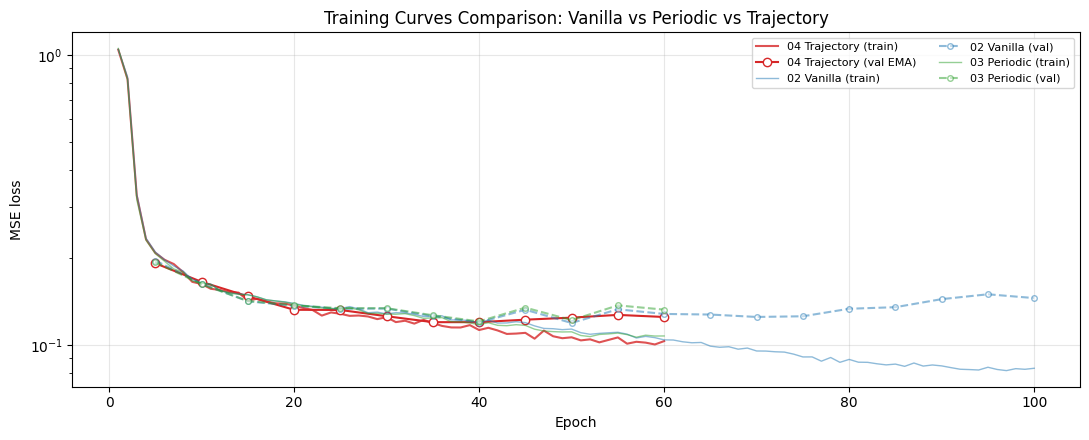

✓ /content/drive/MyDrive/quadruped_diffusion_project/phase_trajectory_loss.png


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(11, 4.5))
ax.plot(np.arange(1, len(train_losses) + 1), train_losses,
        label='04 Trajectory (train)', alpha=0.8, color='tab:red')
if val_log:
    ax.plot([v[0] for v in val_log], [v[1] for v in val_log],
            'o-', label='04 Trajectory (val EMA)', color='tab:red', markerfacecolor='white')

# 이전 단계들과 비교
for name, ckpt_path, color in [
    ('02 Vanilla',  f'{PROJECT_DIR}/vanilla_dp_ckpt.pt',         'tab:blue'),
    ('03 Periodic', f'{PROJECT_DIR}/phase_periodic_ckpt.pt',     'tab:green'),
]:
    if os.path.exists(ckpt_path):
        c = torch.load(ckpt_path, map_location='cpu')
        ax.plot(np.arange(1, len(c['train_losses']) + 1), c['train_losses'],
                label=f'{name} (train)', alpha=0.5, linewidth=1, color=color)
        if c.get('val_log'):
            ax.plot([v[0] for v in c['val_log']], [v[1] for v in c['val_log']],
                    'o--', label=f'{name} (val)', color=color, alpha=0.5,
                    markersize=4, markerfacecolor='white')

ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Training Curves Comparison: Vanilla vs Periodic vs Trajectory')
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3); ax.set_yscale('log')
plt.tight_layout()
out_png = f'{PROJECT_DIR}/phase_trajectory_loss.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

## 9. Best EMA 적용 (학습 직후)

In [11]:
if TRAIN and best_ema_state is not None:
    cur = ema.state_dict()
    cur.update(best_ema_state)
    ema.load_state_dict(cur)
    best_idx = min(range(len(val_log)), key=lambda i: val_log[i][1])
    print(f"✓ Best EMA 적용 (epoch {val_log[best_idx][0]}, val={val_log[best_idx][1]:.5f})")
elif not TRAIN:
    print("Load 경로 — 이미 best EMA 적용됨")

✓ Best EMA 적용 (epoch 35, val=0.11997)


## 10. Phase trajectory function (Step 3과 동일)

In [12]:
DT = 0.05
f_mean = data['freq_window_mean']

def make_phase_traj_fn(freq_hz: float, dt: float = DT):
    def phase_traj(current_step: int, pred_horizon: int):
        t_steps = np.arange(current_step, current_step + pred_horizon)
        phi = (2.0 * np.pi * freq_hz * t_steps * dt) % (2.0 * np.pi)
        return phi.astype(np.float32)
    return phase_traj

# Test
phi = make_phase_traj_fn(f_mean)(0, data['PRED_HORIZON'])
print(f"Test (freq={f_mean:.3f} Hz):")
print(f"  per-step Δφ: {np.diff(np.unwrap(phi)).mean():.4f} rad/step")
print(f"  expected:    {2*np.pi*f_mean*DT:.4f}")

Test (freq=2.023 Hz):
  per-step Δφ: 0.6356 rad/step
  expected:    0.6356


## 11. Offline RMSE — Phase 영향 검증 (vs Step 3 직접 비교)

Step 3과 정확히 같은 sweep. **Step 3에선 Δf=0 vs Δf≠0 binary discrimination만 보였고 (RMSE 0.25 평탄), Step 4에선 Δf↑ 일수록 RMSE 증가가 기대됨.**

In [13]:
ep_obs = torch.stack([val_ds[0]['obs']]).to(device)

freqs_to_test = [
    f_mean,                                          # baseline
    data['freq_window_min'],                         # min
    data['freq_window_max'],                         # max
    f_mean - 3 * data['freq_window_std'],            # mild OOD low
    f_mean + 3 * data['freq_window_std'],            # mild OOD high
    f_mean - 6 * data['freq_window_std'],            # far OOD low (Step 4 추가)
    f_mean + 6 * data['freq_window_std'],            # far OOD high (Step 4 추가)
]
labels = ['mean', 'min', 'max', 'OOD-low', 'OOD-high', 'far-OOD-low', 'far-OOD-high']

# 같은 noise seed 고정해서 deterministic 비교
torch.manual_seed(SEED)
samples_by_freq = {}
for f, lbl in zip(freqs_to_test, labels):
    torch.manual_seed(SEED)  # noise seed 동일
    phi = make_phase_traj_fn(f)(0, data['PRED_HORIZON'])
    phi_t = torch.from_numpy(phi).unsqueeze(0)
    s = sample_action_chunk(
        model, ema, ns_config,
        obs_window=ep_obs, phase_chunk=phi_t,
        cond_fn=trajectory_phase_sample_cond_fn,
        pred_horizon=data['PRED_HORIZON'],
        act_dim=data['ACT_DIM'],
        num_inference_steps=NUM_INFERENCE_STEPS,
        device=device, use_ema=True,
    ).numpy()[0]
    samples_by_freq[lbl] = (f, s)

print(f"=== Output 차이 (L2 distance from 'mean' baseline) ===")
ref = samples_by_freq['mean'][1]
for lbl in labels:
    f, s = samples_by_freq[lbl]
    d = np.linalg.norm(s - ref) / np.sqrt(s.size)
    print(f"  {lbl:>14s} (Δf={f - f_mean:+.3f} Hz): RMSE = {d:.4f}")

print(f"\n→ Step 3 결과: Δf≠0 모두 ~0.25 평탄 (binary discrimination)")
print(f"→ Step 4 기대: Δf↑ 일수록 monotonic 증가 (graded sensitivity)")

=== Output 차이 (L2 distance from 'mean' baseline) ===
            mean (Δf=+0.000 Hz): RMSE = 0.0000
             min (Δf=-0.223 Hz): RMSE = 0.2553
             max (Δf=+0.277 Hz): RMSE = 0.2450
         OOD-low (Δf=-0.307 Hz): RMSE = 0.3035
        OOD-high (Δf=+0.307 Hz): RMSE = 0.2675
     far-OOD-low (Δf=-0.614 Hz): RMSE = 0.3618
    far-OOD-high (Δf=+0.614 Hz): RMSE = 0.4142

→ Step 3 결과: Δf≠0 모두 ~0.25 평탄 (binary discrimination)
→ Step 4 기대: Δf↑ 일수록 monotonic 증가 (graded sensitivity)


## 12. 시각화 — phase별 action chunk 비교

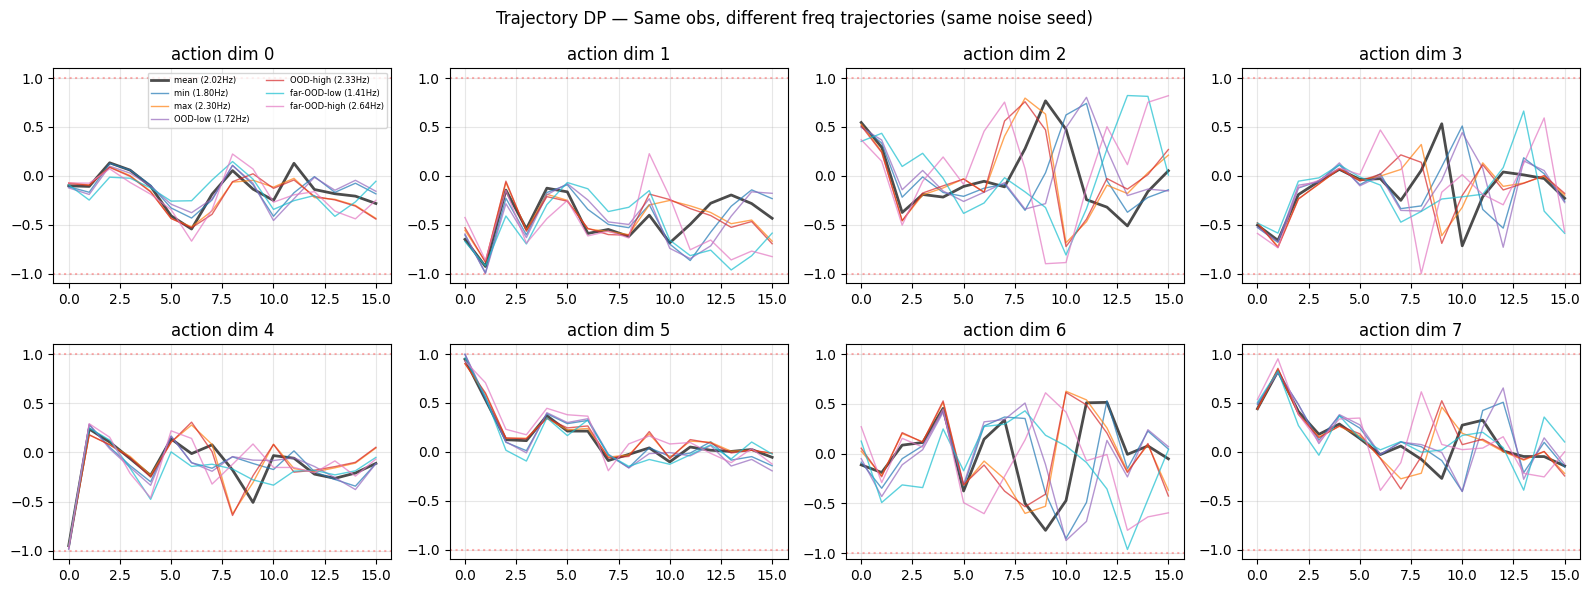

✓ /content/drive/MyDrive/quadruped_diffusion_project/phase_trajectory_freq_sweep.png


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
colors = {
    'mean': 'k', 'min': 'tab:blue', 'max': 'tab:orange',
    'OOD-low': 'tab:purple', 'OOD-high': 'tab:red',
    'far-OOD-low': 'tab:cyan', 'far-OOD-high': 'tab:pink',
}
for d in range(data['ACT_DIM']):
    ax = axes.flat[d]
    for lbl, (f, s) in samples_by_freq.items():
        lw = 2 if lbl == 'mean' else 1
        ax.plot(s[:, d], '-', alpha=0.7, linewidth=lw,
                label=f'{lbl} ({f:.2f}Hz)' if d == 0 else None,
                color=colors[lbl])
    ax.axhline( 1, color='r', ls=':', alpha=0.3)
    ax.axhline(-1, color='r', ls=':', alpha=0.3)
    ax.set_title(f'action dim {d}')
    ax.grid(True, alpha=0.3)
    if d == 0:
        ax.legend(fontsize=6, ncol=2)
plt.suptitle('Trajectory DP — Same obs, different freq trajectories (same noise seed)')
plt.tight_layout()
out_png = f'{PROJECT_DIR}/phase_trajectory_freq_sweep.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

## 13. Rollout — In-distribution mean

In [15]:
import gymnasium as gym
env = gym.make('Ant-v5')

In [16]:
print(f"=== Trajectory DP — Rollout @ f={f_mean:.3f} Hz (in-dist mean) ===\n")

phase_fn_mean = make_phase_traj_fn(f_mean)

results_in = rollout_multi_seed(
    model, ema, env, n_seeds=5,
    noise_scheduler_config=ns_config,
    obs_mean=data['obs_mean'], obs_std=data['obs_std'],
    act_min=data['act_min'], act_range=data['act_range'],
    cond_fn=trajectory_phase_sample_cond_fn,
    obs_horizon=data['OBS_HORIZON'],
    pred_horizon=data['PRED_HORIZON'],
    action_horizon=data['ACTION_HORIZON'],
    obs_dim=data['OBS_DIM'],
    act_dim=data['ACT_DIM'],
    num_inference_steps=NUM_INFERENCE_STEPS,
    max_steps=1000,    # Step 3과 동일하게 1000
    phase_trajectory_fn=phase_fn_mean,
    device=device,
)

=== Trajectory DP — Rollout @ f=2.023 Hz (in-dist mean) ===

  seed 0: survival=155 steps, total_reward=   185.4
  seed 1: survival=1000 steps, total_reward=  1515.6
  seed 2: survival=102 steps, total_reward=   201.4
  seed 3: survival=558 steps, total_reward=  1195.1
  seed 4: survival=552 steps, total_reward=   899.5

Survival:  mean=473 ± 326 steps
Reward:    mean=799.4 ± 531.8


## 14. Controllability sweep — 최종 검증 (메인 결과)

Step 3과 정확히 같은 sweep, max_steps=1000, 3 seed.

**Step 3 결과 (참조)**:
```
freq    | survival       | reward         | zone
1.717   | 1000 ± 0      | 831.0 ± 184.7 | OOD
1.800   | 1000 ± 0      | 809.8 ± 100.3 | in-dist
1.921   |  713 ± 405    | 537.4 ± 232.2 | in-dist
2.023   | 1000 ± 0      | 670.5 ± 355.0 | in-dist (mean)
2.126   | 1000 ± 0      | 901.3 ± 214.5 | in-dist
2.300   | 1000 ± 0      | 890.7 ± 162.1 | in-dist
2.330   | 1000 ± 0      | 813.7 ± 146.8 | OOD
```

**Step 4 기대**:
- In-dist: 안정 보행, reward는 freq에 따라 변할 수 있음
- OOD: 명확한 성능 저하 또는 자빠짐 (controllability의 honest limit)

In [17]:
sweep_freqs = np.array([
    f_mean - 3 * data['freq_window_std'],   # mild OOD
    data['freq_window_min'],                 # in-dist min
    f_mean - data['freq_window_std'],        # in-dist
    f_mean,                                  # in-dist mean
    f_mean + data['freq_window_std'],        # in-dist
    data['freq_window_max'],                 # in-dist max
    f_mean + 3 * data['freq_window_std'],    # mild OOD
])

sweep_results = {}
for f in sweep_freqs:
    phase_fn = make_phase_traj_fn(f)
    label = 'OOD' if (f < data['freq_window_min'] - 0.01
                      or f > data['freq_window_max'] + 0.01) else 'in-dist'
    print(f"\n--- freq={f:.3f} Hz ({label}) ---")
    res = rollout_multi_seed(
        model, ema, env, n_seeds=3,
        noise_scheduler_config=ns_config,
        obs_mean=data['obs_mean'], obs_std=data['obs_std'],
        act_min=data['act_min'], act_range=data['act_range'],
        cond_fn=trajectory_phase_sample_cond_fn,
        obs_horizon=data['OBS_HORIZON'],
        pred_horizon=data['PRED_HORIZON'],
        action_horizon=data['ACTION_HORIZON'],
        obs_dim=data['OBS_DIM'],
        act_dim=data['ACT_DIM'],
        num_inference_steps=NUM_INFERENCE_STEPS,
        max_steps=1000,
        phase_trajectory_fn=phase_fn,
        device=device,
    )
    sweep_results[float(f)] = res


--- freq=1.717 Hz (OOD) ---
  seed 0: survival=1000 steps, total_reward=   227.6
  seed 1: survival=802 steps, total_reward=   589.6
  seed 2: survival=1000 steps, total_reward=   963.6

Survival:  mean=934 ± 93 steps
Reward:    mean=593.6 ± 300.5

--- freq=1.800 Hz (in-dist) ---
  seed 0: survival=404 steps, total_reward=   531.1
  seed 1: survival=1000 steps, total_reward=  1305.3
  seed 2: survival=1000 steps, total_reward=   987.8

Survival:  mean=801 ± 281 steps
Reward:    mean=941.4 ± 317.7

--- freq=1.921 Hz (in-dist) ---
  seed 0: survival=1000 steps, total_reward=   760.9
  seed 1: survival=1000 steps, total_reward=  1628.2
  seed 2: survival=582 steps, total_reward=   695.8

Survival:  mean=861 ± 197 steps
Reward:    mean=1028.3 ± 425.0

--- freq=2.023 Hz (in-dist) ---
  seed 0: survival=667 steps, total_reward=  1073.9
  seed 1: survival=1000 steps, total_reward=  1362.3
  seed 2: survival=1000 steps, total_reward=  1853.8

Survival:  mean=889 ± 157 steps
Reward:    mean=14

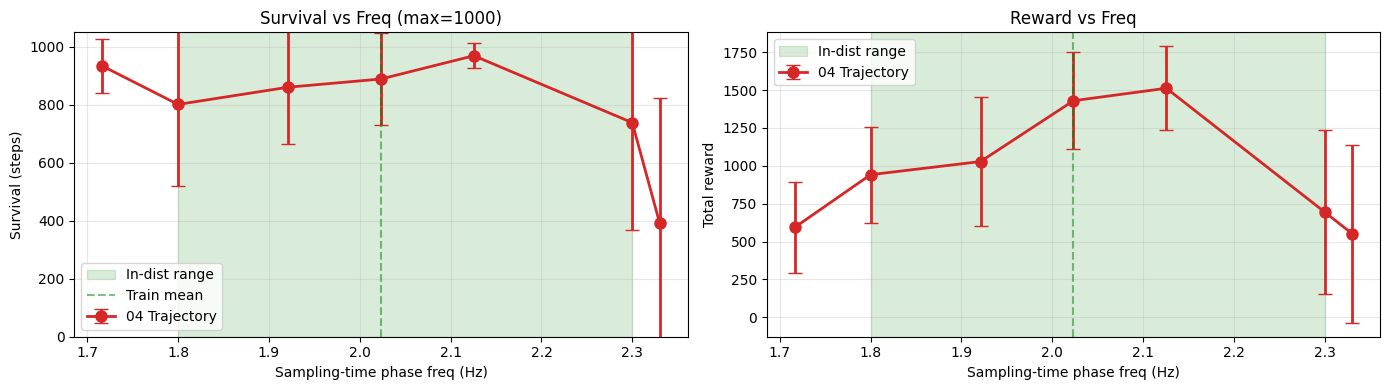

✓ /content/drive/MyDrive/quadruped_diffusion_project/phase_trajectory_controllability.png

=== Step 4 sweep 결과 ===
   freq |      survival |          reward | zone
  1.717 |   934 ±   93 |   593.6 ± 300.5 | OOD
  1.800 |   801 ±  281 |   941.4 ± 317.7 | in-dist
  1.921 |   861 ±  197 |  1028.3 ± 425.0 | in-dist
  2.023 |   889 ±  157 |  1430.0 ± 322.0 | in-dist
  2.126 |   969 ±   43 |  1512.4 ± 278.0 | in-dist
  2.300 |   738 ±  370 |   693.9 ± 541.6 | in-dist
  2.330 |   392 ±  430 |   551.6 ± 589.2 | OOD


In [18]:
sweep_freqs_sorted = sorted(sweep_results.keys())
surv_means = [np.mean([r['survival']     for r in sweep_results[f]]) for f in sweep_freqs_sorted]
surv_stds  = [np.std ([r['survival']     for r in sweep_results[f]]) for f in sweep_freqs_sorted]
rew_means  = [np.mean([r['total_reward'] for r in sweep_results[f]]) for f in sweep_freqs_sorted]
rew_stds   = [np.std ([r['total_reward'] for r in sweep_results[f]]) for f in sweep_freqs_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].errorbar(sweep_freqs_sorted, surv_means, yerr=surv_stds,
                 fmt='o-', capsize=5, linewidth=2, markersize=8, color='tab:red',
                 label='04 Trajectory')
axes[0].axvspan(data['freq_window_min'], data['freq_window_max'],
                alpha=0.15, color='green', label='In-dist range')
axes[0].axvline(f_mean, color='green', ls='--', alpha=0.5, label='Train mean')
axes[0].set_xlabel('Sampling-time phase freq (Hz)')
axes[0].set_ylabel('Survival (steps)')
axes[0].set_title('Survival vs Freq (max=1000)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1050)

axes[1].errorbar(sweep_freqs_sorted, rew_means, yerr=rew_stds,
                 fmt='o-', capsize=5, linewidth=2, markersize=8, color='tab:red',
                 label='04 Trajectory')
axes[1].axvspan(data['freq_window_min'], data['freq_window_max'],
                alpha=0.15, color='green', label='In-dist range')
axes[1].axvline(f_mean, color='green', ls='--', alpha=0.5)
axes[1].set_xlabel('Sampling-time phase freq (Hz)')
axes[1].set_ylabel('Total reward')
axes[1].set_title('Reward vs Freq')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_png = f'{PROJECT_DIR}/phase_trajectory_controllability.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

print(f"\n=== Step 4 sweep 결과 ===")
print(f"{'freq':>7s} | {'survival':>13s} | {'reward':>15s} | zone")
for f in sweep_freqs_sorted:
    surv = np.array([r['survival']     for r in sweep_results[f]])
    rew  = np.array([r['total_reward'] for r in sweep_results[f]])
    zone = 'OOD' if (f < data['freq_window_min'] - 0.01
                     or f > data['freq_window_max'] + 0.01) else 'in-dist'
    print(f"{f:>7.3f} | {surv.mean():>5.0f} ± {surv.std():>4.0f} | "
          f"{rew.mean():>7.1f} ± {rew.std():>5.1f} | {zone}")

## 15. Step 3 vs Step 4 직접 비교 — 핵심 ablation 표

Paper Section 4의 main ablation table.

In [19]:
# Step 3 결과 하드코딩 (이전 sweep 결과)
step3_sweep = {
    1.717: {'survival_mean': 1000, 'survival_std': 0,    'reward_mean': 831.0, 'reward_std': 184.7, 'zone': 'OOD'},
    1.800: {'survival_mean': 1000, 'survival_std': 0,    'reward_mean': 809.8, 'reward_std': 100.3, 'zone': 'in-dist'},
    1.921: {'survival_mean':  713, 'survival_std': 405,  'reward_mean': 537.4, 'reward_std': 232.2, 'zone': 'in-dist'},
    2.023: {'survival_mean': 1000, 'survival_std': 0,    'reward_mean': 670.5, 'reward_std': 355.0, 'zone': 'in-dist'},
    2.126: {'survival_mean': 1000, 'survival_std': 0,    'reward_mean': 901.3, 'reward_std': 214.5, 'zone': 'in-dist'},
    2.300: {'survival_mean': 1000, 'survival_std': 0,    'reward_mean': 890.7, 'reward_std': 162.1, 'zone': 'in-dist'},
    2.330: {'survival_mean': 1000, 'survival_std': 0,    'reward_mean': 813.7, 'reward_std': 146.8, 'zone': 'OOD'},
}

print(f"{'freq':>7s} | {'Step 3 (Periodic)':>30s} | {'Step 4 (Trajectory)':>30s}")
print(f"{'':7s} | {'surv':>10s} {'reward':>15s} | {'surv':>10s} {'reward':>15s}")
print('-' * 85)
for f in sweep_freqs_sorted:
    f3 = step3_sweep.get(round(f, 3))
    s4 = sweep_results[f]
    surv4 = np.array([r['survival']     for r in s4])
    rew4  = np.array([r['total_reward'] for r in s4])
    if f3 is not None:
        print(f"{f:>7.3f} | "
              f"{f3['survival_mean']:>5.0f} ± {f3['survival_std']:>3.0f} "
              f"{f3['reward_mean']:>6.1f} ± {f3['reward_std']:>4.1f}  | "
              f"{surv4.mean():>5.0f} ± {surv4.std():>3.0f} "
              f"{rew4.mean():>6.1f} ± {rew4.std():>4.1f}")
    else:
        print(f"{f:>7.3f} | {'N/A':>30s} | "
              f"{surv4.mean():>5.0f} ± {surv4.std():>3.0f} "
              f"{rew4.mean():>6.1f} ± {rew4.std():>4.1f}")

   freq |              Step 3 (Periodic) |            Step 4 (Trajectory)
        |       surv          reward |       surv          reward
-------------------------------------------------------------------------------------
  1.717 |  1000 ±   0  831.0 ± 184.7  |   934 ±  93  593.6 ± 300.5
  1.800 |  1000 ±   0  809.8 ± 100.3  |   801 ± 281  941.4 ± 317.7
  1.921 |   713 ± 405  537.4 ± 232.2  |   861 ± 197 1028.3 ± 425.0
  2.023 |  1000 ±   0  670.5 ± 355.0  |   889 ± 157 1430.0 ± 322.0
  2.126 |  1000 ±   0  901.3 ± 214.5  |   969 ±  43 1512.4 ± 278.0
  2.300 |  1000 ±   0  890.7 ± 162.1  |   738 ± 370  693.9 ± 541.6
  2.330 |  1000 ±   0  813.7 ± 146.8  |   392 ± 430  551.6 ± 589.2


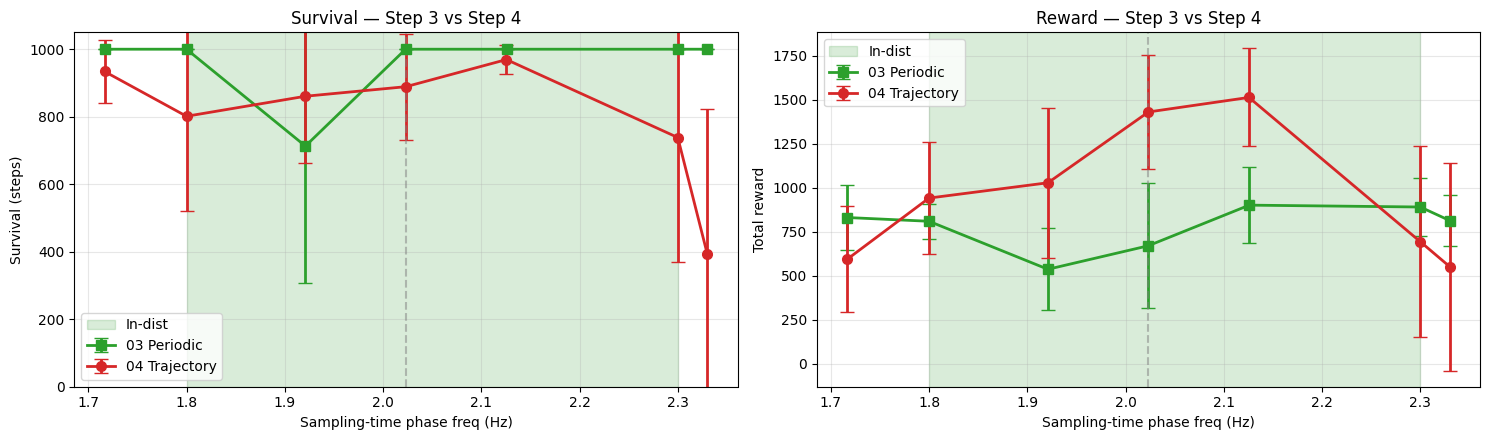

✓ /content/drive/MyDrive/quadruped_diffusion_project/step3_vs_step4_controllability.png


In [20]:
# 시각화: 두 모델의 reward sweep을 한 그래프에
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Survival
s3_freqs = sorted(step3_sweep.keys())
s3_surv  = [step3_sweep[f]['survival_mean'] for f in s3_freqs]
s3_surv_std = [step3_sweep[f]['survival_std'] for f in s3_freqs]
axes[0].errorbar(s3_freqs, s3_surv, yerr=s3_surv_std,
                 fmt='s-', capsize=5, linewidth=2, markersize=7,
                 color='tab:green', label='03 Periodic')
axes[0].errorbar(sweep_freqs_sorted, surv_means, yerr=surv_stds,
                 fmt='o-', capsize=5, linewidth=2, markersize=7,
                 color='tab:red', label='04 Trajectory')
axes[0].axvspan(data['freq_window_min'], data['freq_window_max'],
                alpha=0.15, color='green', label='In-dist')
axes[0].axvline(f_mean, color='gray', ls='--', alpha=0.5)
axes[0].set_xlabel('Sampling-time phase freq (Hz)')
axes[0].set_ylabel('Survival (steps)')
axes[0].set_title('Survival — Step 3 vs Step 4')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1050)

# Reward
s3_rew = [step3_sweep[f]['reward_mean'] for f in s3_freqs]
s3_rew_std = [step3_sweep[f]['reward_std'] for f in s3_freqs]
axes[1].errorbar(s3_freqs, s3_rew, yerr=s3_rew_std,
                 fmt='s-', capsize=5, linewidth=2, markersize=7,
                 color='tab:green', label='03 Periodic')
axes[1].errorbar(sweep_freqs_sorted, rew_means, yerr=rew_stds,
                 fmt='o-', capsize=5, linewidth=2, markersize=7,
                 color='tab:red', label='04 Trajectory')
axes[1].axvspan(data['freq_window_min'], data['freq_window_max'],
                alpha=0.15, color='green', label='In-dist')
axes[1].axvline(f_mean, color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('Sampling-time phase freq (Hz)')
axes[1].set_ylabel('Total reward')
axes[1].set_title('Reward — Step 3 vs Step 4')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_png = f'{PROJECT_DIR}/step3_vs_step4_controllability.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

## 16. 요약 + 결과 해석 가이드

**완료**:
- Per-step FiLM 기반 `PhaseConditionedUnet1D` 구현 + zero-init 검증
- Trajectory phase conditioning으로 학습 (60 epoch)
- Step 3와 동일한 sweep으로 직접 비교

**Drive 산출물**:
- `phase_trajectory_ckpt.pt`
- `phase_trajectory_loss.png`
- `phase_trajectory_freq_sweep.png`
- `phase_trajectory_controllability.png`
- `step3_vs_step4_controllability.png` (메인 figure)

**해석 시나리오**:

**시나리오 A — 깔끔한 contribution 입증** ★★★
- §11 RMSE: Δf↑ 일수록 RMSE monotonic 증가
- §14 sweep: in-dist에서 reward 변화, OOD에서 명확한 저하 (자빠지거나 reward dip)
- §15 비교: Step 4가 Step 3 대비 Δreward(in vs OOD) 차이 큼
- → Phase Trajectory Conditioning을 프로젝트의 main contribution으로 사용. Paper 본문 메인 결과.

**시나리오 B — 부분 입증**
- §11 RMSE는 monotonic 증가하지만 §14 reward는 평탄
- 의미: 모델이 phase trajectory를 받지만 실제 보행에 반영 안 함
- 가능 원인: per-step encoder 학습률 부족, zero-init 너무 강함
- 대응: per-step encoder만 lr 10× 적용 또는 zero-init 약화

**시나리오 C — Step 3과 차이 없음**
- §11 RMSE도 평탄
- 의미: per-step FiLM 자체가 작동 안 함
- 진단: §4 zero-init 검증 결과부터 다시 봄, training.py의 cond_fn 입력 형식 검증

**다음 단계 (`05_evaluation.ipynb`)**:
- Vanilla, Periodic Phase, Phase Trajectory 모델을 동일 protocol로 정밀 평가
- Phase Trajectory Conditioning을 main contribution으로 정리
- 평가 raw 결과와 paper figure를 생성
